# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mathu2112/FlyRank-ML-Internship-Repo/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

---

Research Question

This study investigates whether a data-driven Decision Tree classifier can identify low-click-through-rate (CTR) search observations more effectively than a hand-written rule-based baseline.

<br>

The practical decision underlying this research is whether a machine-learning approach provides sufficient improvement to justify replacing or supplementing an existing rule-based method for identifying potential CTR opportunities.The Decision Tree is therefore evaluated against the week 4 baseline using the same held-out test set and evaluation metrics. This design allows the added complexity of a learned model to be assessed against a simpler,interpretable approach under comparable conditions.

# **Data**

The analysis uses the FlyRank/internship-warehouse dataset, specifically the fact_content_daily_performance table from the training split. The loaded release contains 78,835,655 observations. For computational efficiency and consistency with the earlier analysis, a fixed sample of the first 1,000,000 observations was used for the signal audit and modeling analysis. This sample covers the period from 27 January 2025 to 26 June 2025.

The analysis focuses on Google Search Console (GSC) performance fields, including impressions, clicks, and average search position. Click-through rate (CTR) was calculated as clicks divided by impressions, with observations having zero impressions treated as having missing CTR.

Before modeling, observations were restricted to those with at least 100 impressions. This threshold was used to exclude very low-volume observations where CTR can be highly unstable and less useful for decision support. No observations were excluded because of unavailable GSC data in the analyzed sample. After applying the eligibility criteria, 67,650 observations remained from the 1,000,000-row sample, while 932,350 observations were excluded because they had fewer than 100 impressions.

For the modeling task, the target was defined using the median CTR of the eligible observations (0.00270). Observations below this threshold were labeled as low-CTR observations. The resulting target was approximately balanced, with 33,818 low-CTR observations (49.99%) and 33,832 observations at or above the median (50.01%).

Only aggregated performance fields required for the analysis were used in the public-facing research artifact. No client names, private search queries, addresses, credentials, or other private identifiers are included.

In [ ]:
# ============================================================
# DATA DESCRIPTION AND ELIGIBILITY CHECK
# ============================================================

from google.colab import userdata
import numpy as np
import pandas as pd
from datasets import load_dataset

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

HF_TOKEN = userdata.get("HF_TOKEN")

dataset = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    token=HF_TOKEN
)

# Use the training split
data = dataset["train"]

print("Dataset: FlyRank/internship-warehouse")
print("Table: fact_content_daily_performance")
print("Split: train")
print("Total rows in loaded split:", len(data))


# ------------------------------------------------------------
# 2. Select the analysis sample
# ------------------------------------------------------------

SAMPLE_SIZE = 1_000_000

sample = data.select(range(SAMPLE_SIZE))

# Convert only the analysis sample to pandas
df = sample.to_pandas()

print("\nAnalysis sample:")
print("Rows:", len(df))
print("Columns:", len(df.columns))


# ------------------------------------------------------------
# 3. Date window of the analyzed sample
# ------------------------------------------------------------

sample_dates = pd.to_datetime(df["report_date"])

print("\nAnalyzed sample date window:")
print("Earliest:", sample_dates.min().date())
print("Latest:", sample_dates.max().date())


# ------------------------------------------------------------
# 4. Calculate CTR
# ------------------------------------------------------------

df["ctr"] = np.where(
    df["gsc_impressions"] > 0,
    df["gsc_clicks"] / df["gsc_impressions"],
    np.nan
)


# ------------------------------------------------------------
# 5. Apply eligibility criteria
# ------------------------------------------------------------

eligible = df[
    (df["gsc_data_available"] == True) &
    (df["gsc_impressions"] >= 100)
].copy()

print("\nEligibility filtering:")
print("Initial sample:", len(df))
print("Eligible observations:", len(eligible))
print("Excluded observations:", len(df) - len(eligible))


# ------------------------------------------------------------
# 6. Report exclusion reasons
# ------------------------------------------------------------

missing_gsc = (
    df["gsc_data_available"] != True
)

low_impressions = (
    df["gsc_impressions"] < 100
)

print("\nExclusion checks:")
print(
    "Rows without available GSC data:",
    missing_gsc.sum()
)

print(
    "Rows with fewer than 100 impressions:",
    low_impressions.sum()
)


# ------------------------------------------------------------
# 7. Define the modeling target
# ------------------------------------------------------------

ctr_threshold = eligible["ctr"].median()

eligible["target_low_ctr"] = (
    eligible["ctr"] < ctr_threshold
).astype(int)

print("\nCTR target definition:")
print("Median CTR threshold:", ctr_threshold)

print("\nTarget distribution:")
print(
    eligible["target_low_ctr"].value_counts()
)

print("\nTarget distribution (%):")
print(
    eligible["target_low_ctr"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# ------------------------------------------------------------
# 8. Public-safe analytical fields
# ------------------------------------------------------------

print("\nPublic-safe analytical fields:")

print([
    "report_date",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ctr"
])

README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 8.93MB            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 7.12MB            

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B / 1.45MB            

...

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  146MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/78835655 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/39 [00:00<?, ?it/s]

Dataset: FlyRank/internship-warehouse
Table: fact_content_daily_performance
Split: train
Total rows in loaded split: 78835655

Analysis sample:
Rows: 1000000
Columns: 30

Analyzed sample date window:
Earliest: 2025-01-27
Latest: 2025-06-26

Eligibility filtering:
Initial sample: 1000000
Eligible observations: 67650
Excluded observations: 932350

Exclusion checks:
Rows without available GSC data: 0
Rows with fewer than 100 impressions: 932350

CTR target definition:
Median CTR threshold: 0.002702702702702703

Target distribution:
target_low_ctr
0    33832
1    33818
Name: count, dtype: int64

Target distribution (%):
target_low_ctr
0    50.01
1    49.99
Name: proportion, dtype: float64

Public-safe analytical fields:
['report_date', 'gsc_impressions', 'gsc_clicks', 'gsc_avg_position', 'ctr']


# **Methodology**

**3.1 Analytical Design**


This study compares a transparent, hand-written rule-based baseline with a Decision Tree classifier for identifying observations that may represent low-CTR opportunities. The rule-based baseline was developed from the Week 4 signal audit, while the Decision Tree was selected because it provides interpretable decision rules based on feature thresholds.

The purpose of the comparison is not to assume that the machine-learning model will outperform the baseline. Instead, the analysis evaluates whether a data-driven model can improve upon the existing rule when both approaches are tested on the same observations using the same evaluation metrics.

**3.2 Data and Analytical Population**

The analysis uses the fact_content_daily_performance table from the FlyRank/internship-warehouse dataset. The analysis was conducted using the train split, which contains 78,835,655 observations.

For the modelling analysis, a fixed sample of 1,000,000 observations was selected using the first 1,000,000 rows of the training split, consistent with the Week 4 analysis. The sampled observations cover the observed report-date range from 27 January 2025 to 26 June 2025.

CTR was calculated as Google Search Console clicks divided by Google Search Console impressions. Observations with unavailable GSC data or fewer than 100 impressions were excluded from the modelling population. In the analysed sample, all observations had GSC data available, while 932,350 observations were excluded because they had fewer than 100 impressions, leaving 67,650 eligible observations.

Only public-safe analytical fields and aggregate performance measures were used. No client names, URLs, or private search queries were included in the analysis.

**3.3 CTR and Target Definition**

CTR was calculated as Google Search Console clicks divided by Google Search Console impressions. Where impressions were zero or unavailable, CTR was treated as missing because a meaningful click-through rate cannot be calculated without impressions.

For classification, the modelling population consisted of observations with available GSC data and at least 100 impressions. The binary target was defined using the median CTR among these eligible observations.

Observations with CTR below the median were labelled 1 (low CTR), while observations with CTR equal to or above the median were labelled 0 (non-low CTR). The observed median CTR was 0.0027027, resulting in an approximately balanced target: 49.99% low CTR and 50.01% non-low CTR.

**3.4 Baseline Rule**

The Week 4 baseline is a transparent rule designed to identify potential CTR improvement opportunities. An observation is flagged when all three of the following conditions are satisfied:

Average search position is greater than 0 and no worse than position 20.
Google Search Console impressions are at least 100.
CTR is below 0.005, equivalent to 0.5%.

Observations satisfying all three conditions are assigned the reason code LOW_CTR_GOOD_POSITION and the action label INVESTIGATE_CTR.

For prioritisation, an action score combines impression volume with the gap between the observed CTR and the 0.005 threshold. Higher visibility and a larger CTR gap therefore produce a higher priority score. The resulting queue is intended as decision support for investigation, rather than proof that a specific content intervention is required.

**3.5 Signal Selection**

Signal selection was informed by the Week 6 signal audit. Two main signals were examined: search position and impression volume.

Search position showed a clear relationship with CTR. Mean CTR decreased as search position became worse, falling from 0.016720 for positions 1–3 to 0.000404 for positions 51+. This observed pattern supported the use of search position as contextual information when interpreting CTR.

Impression volume showed a mixed relationship with CTR. Mean CTR did not display a consistent monotonic pattern across impression-volume groups. Nevertheless, impressions were retained in the baseline as a prioritisation variable because greater search visibility can make a potential opportunity more consequential.

**3.6 Model Features and Configuration**

The Decision Tree used 14 aggregate performance features covering Google Search Console position, Google Analytics engagement, traffic sources, and scrolling behaviour:

gsc_avg_position




* gsc_sum_position
* ga4_pageviews
* ga4_sessions
* ga4_users
* ga4_engaged_sessions
* ga4_total_engagement_sec
* sessions_organic
* sessions_direct
* sessions_referral
* sessions_social
* sessions_paid
* sessions_ai
* scroll_events

The Decision Tree was configured with a maximum depth of 5, a minimum leaf size of 50 observations, and random_state=42. These constraints were used to keep the learned decision rules relatively simple and reduce highly fragmented branches.

Importantly, clicks and impressions were not included as model features, because they were used to construct the CTR target. This reduces the risk of the model directly reproducing the target definition.

**3.7 Validation Design**

The eligible observations were divided into training and testing partitions using an 80/20 stratified random split with random_state=42. Stratification was used to maintain approximately equal proportions of low-CTR and non-low-CTR observations in both partitions.

The resulting training set contained 54,120 observations, while the held-out test set contained 13,530 observations.

Both the Week 4 baseline and the Decision Tree were evaluated on exactly the same held-out observations. This provides a consistent basis for comparing the two approaches.

Performance was evaluated using accuracy, precision, recall, and F1 score. F1 was treated as an important comparison metric because it combines precision and recall into a single measure.


**3.8 Model Training and Comparison**

The Decision Tree was trained on the training partition and then used to generate predictions for the held-out test partition.

For comparison, the Week 4 baseline rule was applied to the same test observations. Both approaches were therefore evaluated against the same target labels and using the same metrics.

The baseline achieved an accuracy of 0.7841 and an F1 score of 0.7768, while the Decision Tree achieved an accuracy of 0.6589 and an F1 score of 0.6480.

Under this experimental setup, the Week 4 rule therefore performed better than the Decision Tree across the reported classification metrics.


**3.9 Feature Importance and Error Analysis**

The fitted Decision Tree relied primarily on search-position variables. gsc_avg_position accounted for approximately 94.1% of the model's feature importance, while gsc_sum_position accounted for approximately 5.9%. The remaining features had zero measured importance in the fitted tree.

The largest error group for the Decision Tree was false negatives, with 2,516 observations. These observations were classified as non-low-CTR even though they belonged to the low-CTR target class. Their mean search position was approximately 6.35, indicating that some observations with relatively strong search positions still had low CTR.

This suggests that search position alone does not fully capture the factors associated with low CTR in the analysed data.

**3.10 Leakage Checks and Assumptions**

The target variable was constructed from CTR, which itself was calculated from GSC clicks and impressions. These target-definition variables were therefore excluded from the Decision Tree feature set. The model instead used search-position, engagement, traffic-source, and scrolling features.

The modelling population was also restricted to observations with available GSC data and at least 100 impressions. This filtering was applied before constructing the target.

The validation design used a stratified random split rather than a client-grouped or time-aware split. Therefore, the results should be interpreted specifically as performance under the selected experimental split. They should not be interpreted as evidence that the Decision Tree will perform identically on future dates or entirely unseen clients

In [ ]:
# ============================================================
# 3.2 DATA AND ANALYTICAL POPULATION
# ============================================================

import numpy as np
import pandas as pd

print("Dataset: FlyRank/internship-warehouse")
print("Table: fact_content_daily_performance")
print("Split: train")
print("Total rows:", len(data))

# Analysis sample
SAMPLE_SIZE = 1_000_000
sample = data.select(range(SAMPLE_SIZE))
df = sample.to_pandas()

print("\nAnalysis sample")
print("Rows:", len(df))
print("Columns:", len(df.columns))

# Date range of the actual analysis sample
sample_dates = pd.to_datetime(df["report_date"])

print("\nAnalysis date window")
print("Earliest:", sample_dates.min().date())
print("Latest:", sample_dates.max().date())

# Calculate CTR
df["ctr"] = np.where(
    df["gsc_impressions"] > 0,
    df["gsc_clicks"] / df["gsc_impressions"],
    np.nan
)

# Eligibility criteria
eligible = df[
    (df["gsc_data_available"] == True) &
    (df["gsc_impressions"] >= 100)
].copy()

print("\nEligibility results")
print("Initial observations:", len(df))
print("Eligible observations:", len(eligible))
print("Excluded observations:", len(df) - len(eligible))

print("\nExclusion reasons")
print(
    "Without GSC data:",
    (df["gsc_data_available"] != True).sum()
)

print(
    "Fewer than 100 impressions:",
    (df["gsc_impressions"] < 100).sum()
)

# ============================================================
# 3.3 CTR AND TARGET DEFINITION
# ============================================================

# Calculate the median CTR among eligible observations
ctr_threshold = eligible["ctr"].median()

# Create binary target
eligible["target_low_ctr"] = (
    eligible["ctr"] < ctr_threshold
).astype(int)

print("Median CTR threshold:", ctr_threshold)

print("\nTarget counts:")
print(
    eligible["target_low_ctr"].value_counts()
)

print("\nTarget percentages:")
print(
    eligible["target_low_ctr"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
# ============================================================
# 3.4 WEEK 4 BASELINE RULE
# ============================================================

baseline_df = eligible.copy()

# Rule conditions
good_position = (
    (baseline_df["gsc_avg_position"] > 0) &
    (baseline_df["gsc_avg_position"] <= 20)
)

enough_impressions = (
    baseline_df["gsc_impressions"] >= 100
)

low_ctr = (
    baseline_df["ctr"] < 0.005
)

# Flag observations
baseline_df["flagged"] = (
    good_position &
    enough_impressions &
    low_ctr
)

# Action score
baseline_df["action_score"] = 0.0

baseline_df.loc[
    baseline_df["flagged"],
    "action_score"
] = (
    np.log1p(
        baseline_df.loc[
            baseline_df["flagged"],
            "gsc_impressions"
        ]
    )
    *
    (
        0.005 -
        baseline_df.loc[
            baseline_df["flagged"],
            "ctr"
        ]
    )
)

# Reason code
baseline_df["reason_code"] = np.where(
    baseline_df["flagged"],
    "LOW_CTR_GOOD_POSITION",
    "NOT_FLAGGED"
)

# Action label
baseline_df["action_label"] = np.where(
    baseline_df["flagged"],
    "INVESTIGATE_CTR",
    "NO_ACTION"
)

# Ranked queue
ranked_queue = (
    baseline_df[baseline_df["flagged"]]
    .sort_values(
        "action_score",
        ascending=False
    )
    .reset_index(drop=True)
)

ranked_queue.index = ranked_queue.index + 1
ranked_queue.index.name = "rank"

print("Number of flagged observations:",
      len(ranked_queue))

display(ranked_queue.head(10))
# ============================================================
# 3.5 SIGNAL CHECK
# ============================================================

# Search-position buckets
position_bins = [
    -float("inf"), 3, 10, 20, 50, float("inf")
]

position_labels = [
    "1-3", "4-10", "11-20", "21-50", "51+"
]

eligible["position_bucket"] = pd.cut(
    eligible["gsc_avg_position"],
    bins=position_bins,
    labels=position_labels
)

position_summary = (
    eligible
    .dropna(subset=["ctr", "position_bucket"])
    .groupby("position_bucket", observed=True)
    .agg(
        n=("ctr", "count"),
        mean_ctr=("ctr", "mean")
    )
    .reset_index()
)

print("CTR by search-position bucket")
display(position_summary)


# Impression-volume buckets
volume_bins = [
    -1, 0, 10, 100, 1000, float("inf")
]

volume_labels = [
    "0", "1-10", "11-100", "101-1000", "1000+"
]

eligible["volume_bucket"] = pd.cut(
    eligible["gsc_impressions"],
    bins=volume_bins,
    labels=volume_labels
)

volume_summary = (
    eligible
    .dropna(subset=["volume_bucket"])
    .groupby("volume_bucket", observed=True)
    .agg(
        n=("ctr", "count"),
        mean_ctr=("ctr", "mean")
    )
    .reset_index()
)

print("CTR by impression-volume bucket")
display(volume_summary)

# ============================================================
# 3.6 MODEL FEATURES
# ============================================================

feature_cols = [
    "gsc_avg_position",
    "gsc_sum_position",
    "ga4_pageviews",
    "ga4_sessions",
    "ga4_users",
    "ga4_engaged_sessions",
    "ga4_total_engagement_sec",
    "sessions_organic",
    "sessions_direct",
    "sessions_referral",
    "sessions_social",
    "sessions_paid",
    "sessions_ai",
    "scroll_events"
]

X = eligible[feature_cols].copy()
y = eligible["target_low_ctr"]

print("Number of features:", len(feature_cols))
print("Feature matrix:", X.shape)
print("Target vector:", y.shape)

print("\nMissing values:")
print(X.isnull().sum())

# Leakage check
leakage_fields = [
    "gsc_clicks",
    "gsc_impressions",
    "ctr"
]

print("\nTarget-definition fields excluded from features:")
print(leakage_fields)

print("\nFeatures used:")
for feature in feature_cols:
    print("-", feature)
# ============================================================
# 3.7 TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(
    y_train.value_counts(normalize=True)
)

print("\nTest target distribution:")
print(
    y_test.value_counts(normalize=True)
)

# ============================================================
# 3.8 MODEL TRAINING AND COMPARISON
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Week 4 baseline on test set
# ------------------------------------------------------------

test_data = eligible.loc[X_test.index].copy()

baseline_test_pred = (
    (test_data["gsc_avg_position"] > 0) &
    (test_data["gsc_avg_position"] <= 20) &
    (test_data["gsc_impressions"] >= 100) &
    (test_data["ctr"] < 0.005)
).astype(int)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_test_pred
)

baseline_precision = precision_score(
    y_test,
    baseline_test_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_test_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_test_pred,
    zero_division=0
)

# ------------------------------------------------------------
# Decision Tree
# ------------------------------------------------------------

tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_test_pred = tree_model.predict(X_test)

tree_accuracy = accuracy_score(
    y_test,
    tree_test_pred
)

tree_precision = precision_score(
    y_test,
    tree_test_pred,
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    tree_test_pred,
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    tree_test_pred,
    zero_division=0
)

# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Week 4 Rule Baseline",
        "Decision Tree"
    ],
    "Accuracy": [
        baseline_accuracy,
        tree_accuracy
    ],
    "Precision": [
        baseline_precision,
        tree_precision
    ],
    "Recall": [
        baseline_recall,
        tree_recall
    ],
    "F1 Score": [
        baseline_f1,
        tree_f1
    ]
})

display(
    comparison.round(4)
)
# ============================================================
# 3.9 FEATURE IMPORTANCE AND ERROR ANALYSIS
# ============================================================

# Feature importance
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": tree_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("Decision Tree feature importance:")
display(feature_importance)


# Confusion matrix
tree_cm = confusion_matrix(
    y_test,
    tree_test_pred
)

print("\nDecision Tree confusion matrix:")
print(tree_cm)


# False negatives
false_negative_mask = (
    (y_test == 1) &
    (tree_test_pred == 0)
)

false_negatives = eligible.loc[
    X_test.index[false_negative_mask]
].copy()

print("\nFalse negatives:", len(false_negatives))

print(
    "Mean search position among false negatives:",
    false_negatives["gsc_avg_position"].mean()
)
# ============================================================
# 3.10 LEAKAGE AND DATA CHECKS
# ============================================================

# Check that target-definition fields are not model features
target_definition_fields = {
    "gsc_clicks",
    "gsc_impressions",
    "ctr"
}

feature_set = set(feature_cols)

leakage_overlap = target_definition_fields.intersection(
    feature_set
)

print("Potential leakage fields included in features:")
print(leakage_overlap)

if len(leakage_overlap) == 0:
    print("PASS: No target-definition fields are included in model features.")
else:
    print("WARNING: Potential leakage detected.")


# Check split sizes
print("\nValidation split:")
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nRandom state: 42")
print("Test proportion: 20%")
print("Stratification: target_low_ctr")

Dataset: FlyRank/internship-warehouse
Table: fact_content_daily_performance
Split: train
Total rows: 78835655

Analysis sample
Rows: 1000000
Columns: 30

Analysis date window
Earliest: 2025-01-27
Latest: 2025-06-26

Eligibility results
Initial observations: 1000000
Eligible observations: 67650
Excluded observations: 932350

Exclusion reasons
Without GSC data: 0
Fewer than 100 impressions: 932350
Median CTR threshold: 0.002702702702702703

Target counts:
target_low_ctr
0    33832
1    33818
Name: count, dtype: int64

Target percentages:
target_low_ctr
0    50.01
1    49.99
Name: proportion, dtype: float64
Number of flagged observations: 31715


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,ai_claude,ai_meta,ai_other,scroll_events,ctr,target_low_ctr,flagged,action_score,reason_code,action_label
rank,,,,,,,,,,,,,,,,,,,,,
1,2025-05-07,client_9958f0a7ae1df715,content_641bed4d0ac6954f,True,True,True,False,3350,0,18086.0,...,0,0,0,0,0.0,1,True,0.040585,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
2,2025-05-09,client_9958f0a7ae1df715,content_641bed4d0ac6954f,True,True,True,False,3330,0,19921.0,...,0,0,0,0,0.0,1,True,0.040555,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
3,2025-05-05,client_73cda7b4e4f265ea,content_cf651123f1085418,True,True,True,False,3089,0,26577.0,...,0,0,0,0,0.0,1,True,0.040180,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
4,2025-05-01,client_73cda7b4e4f265ea,content_cf651123f1085418,True,True,True,False,3049,0,26490.0,...,0,0,0,0,0.0,1,True,0.040114,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
5,2025-04-10,client_73cda7b4e4f265ea,content_cf651123f1085418,True,True,True,False,2864,0,24313.0,...,0,0,0,0,0.0,1,True,0.039802,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
6,2025-05-11,client_9958f0a7ae1df715,content_641bed4d0ac6954f,True,True,True,False,2848,0,16182.0,...,0,0,0,0,0.0,1,True,0.039774,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
7,2025-05-31,client_73cda7b4e4f265ea,content_cf651123f1085418,True,True,True,False,2835,0,22715.0,...,0,0,0,0,0.0,1,True,0.039751,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
8,2025-05-10,client_9958f0a7ae1df715,content_641bed4d0ac6954f,True,True,True,False,2793,0,16556.0,...,0,0,0,0,0.0,1,True,0.039676,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
9,2025-05-17,client_fef1a8f436438636,content_811c0e6db6e2cb7b,True,True,True,False,2234,0,15175.0,...,0,0,0,0,0.0,1,True,0.038560,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR


CTR by search-position bucket


,position_bucket,n,mean_ctr
0,1-3,2099,0.009921
1,4-10,45322,0.006723
2,11-20,11060,0.004061
3,21-50,4766,0.001679
4,51+,4403,0.000118


CTR by impression-volume bucket


...

Number of features: 14
Feature matrix: (67650, 14)
Target vector: (67650,)

Missing values:
gsc_avg_position            0
gsc_sum_position            0
ga4_pageviews               0
ga4_sessions                0
ga4_users                   0
ga4_engaged_sessions        0
ga4_total_engagement_sec    0
sessions_organic            0
sessions_direct             0
sessions_referral           0
sessions_social             0
sessions_paid               0
sessions_ai                 0
scroll_events               0
dtype: int64

Target-definition fields excluded from features:
['gsc_clicks', 'gsc_impressions', 'ctr']

Features used:
- gsc_avg_position
- gsc_sum_position
- ga4_pageviews
- ga4_sessions
- ga4_users
- ga4_engaged_sessions
- ga4_total_engagement_sec
- sessions_organic
- sessions_direct
- sessions_referral
- sessions_social
- sessions_paid
- sessions_ai
- scroll_events
Training set: (54120, 14)
Test set: (13530, 14)

Training target distribution:
target_low_ctr
0    0.500111
1    0.4

,Model,Accuracy,Precision,Recall,F1 Score
0,Week 4 Rule Baseline,0.7841,0.8039,0.7515,0.7768
1,Decision Tree,0.6589,0.6693,0.6280,0.6480


Decision Tree feature importance:


,feature,importance
0,gsc_avg_position,0.940506
1,gsc_sum_position,0.059494
2,ga4_pageviews,0.000000
3,ga4_sessions,0.000000
4,ga4_users,0.000000
5,ga4_engaged_sessions,0.000000
6,ga4_total_engagement_sec,0.000000
7,sessions_organic,0.000000
8,sessions_direct,0.000000
9,sessions_referral,0.000000



Decision Tree confusion matrix:
[[4667 2099]
 [2516 4248]]

False negatives: 2516
Mean search position among false negatives: 6.353894107390917
Potential leakage fields included in features:
set()
PASS: No target-definition fields are included in model features.

Validation split:
Training observations: 54120
Testing observations: 13530

Random state: 42
Test proportion: 20%
Stratification: target_low_ctr


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

---


The Week 4 rule-based baseline performed better than the Decision Tree on the same held-out test set.

The baseline achieved 0.7841 accuracy, 0.8039 precision, 0.7515 recall, and 0.7768 F1 score. The Decision Tree achieved 0.6589 accuracy, 0.6693 precision, 0.6280 recall, and 0.6480 F1 score.

The baseline therefore outperformed the Decision Tree across all four evaluation metrics. The F1 score was 0.1288 higher for the baseline.

This result indicates that the tested Decision Tree did not provide an improvement over the existing rule-based approach under this experimental setup. The result should not be interpreted as evidence that machine-learning approaches are generally worse than rule-based approaches. Instead, it shows that the particular feature set, target definition, Decision Tree configuration, and validation split used in this analysis did not produce an improvement over the baseline.

The Decision Tree also relied mainly on search-position features. `gsc_avg_position` accounted for approximately 94.1% of feature importance and `gsc_sum_position` accounted for approximately 5.9%. The remaining features had zero measured importance in the fitted tree.

The Decision Tree confusion matrix was:

[[4667, 2099],
 [2516, 4248]]

There were 2,516 false negatives. These were observations labelled as low CTR by the target definition but predicted as non-low CTR by the Decision Tree. Their mean search position was approximately 6.35.

Overall, the results support retaining the transparent Week 4 rule as the stronger decision-support approach in this experiment.

In [ ]:
# ============================================================
# 4. RESULTS — MODEL VS BASELINE
# ============================================================

display(comparison.round(4))

print("F1 difference (Baseline - Decision Tree):")
print(round(baseline_f1 - tree_f1, 4))

print("\nDecision Tree confusion matrix:")
print(confusion_matrix(y_test, tree_test_pred))

,Model,Accuracy,Precision,Recall,F1 Score
0,Week 4 Rule Baseline,0.7841,0.8039,0.7515,0.7768
1,Decision Tree,0.6589,0.6693,0.6280,0.6480


F1 difference (Baseline - Decision Tree):
0.1288

Decision Tree confusion matrix:
[[4667 2099]
 [2516 4248]]


## 5. Limitations

This analysis has several limitations.

First, the modelling analysis uses a fixed sample of 1,000,000 observations from the training split rather than the entire 78.8 million-row warehouse. The findings therefore describe the analysed sample and should not automatically be generalised to the complete warehouse.

Second, the validation uses an 80/20 stratified random split. It is not a time-aware split and does not group observations by client or content. Therefore, the results do not establish how the model would perform on future dates or completely unseen clients.

Third, the low-CTR target is defined using the median CTR of the eligible observations. This creates an approximately balanced classification problem, but the median threshold is an analytical definition rather than a business-defined threshold for poor CTR.

Fourth, only 14 features were used by the Decision Tree. Other potentially useful signals may exist in the warehouse but were not included in this experiment.

Fifth, the analysis measures associations and predictive performance. It does not establish that search position, engagement, traffic source, or another variable causes CTR changes.

Finally, the ranked recommendations are intended for investigation and decision support. A flagged observation should not automatically trigger a content change. Human review and additional context are required before taking action.

## 6. Ranked recommendations

The analysis produces a ranked decision-support queue using the Week 4 rule-based baseline.

The baseline flagged 31,715 observations as potential CTR opportunities. These observations satisfy the conditions of having a search position between 1 and 20, at least 100 GSC impressions, and CTR below 0.005.

The recommended actions are:

1. **Investigate high-impression, low-CTR observations first.** These observations have meaningful search visibility but relatively weak click capture and therefore receive higher priority in the action queue.

2. **Review the context of flagged observations before making changes.** A low CTR does not by itself prove that a title, description, or page needs to be changed.

3. **Prioritise repeated or consistently low-CTR observations.** Repeated signals may provide stronger evidence for investigation than a single isolated observation.

4. **Use search position as supporting context.** The signal analysis showed that CTR generally decreases as search position becomes worse, but low CTR can also occur at relatively strong search positions.

5. **Use the machine-learning model as an analytical diagnostic rather than the primary ranking method.** The Decision Tree did not outperform the Week 4 baseline in this experiment, so there is no evidence from this analysis that it should replace the existing rule.

The ranked queue is therefore intended to help decide which observations should be investigated first. It is not an automated content-optimisation system.

In [ ]:
# ============================================================
# 6. RANKED RECOMMENDATIONS
# ============================================================

print("Number of flagged observations:", len(ranked_queue))

recommendation_cols = [
    "report_date",
    "gsc_impressions",
    "gsc_avg_position",
    "ctr",
    "action_score",
    "reason_code",
    "action_label"
]

print("\nTop 10 ranked recommendations:")

display(
    ranked_queue[recommendation_cols].head(10)
)

Number of flagged observations: 31715

Top 10 ranked recommendations:


,report_date,gsc_impressions,gsc_avg_position,ctr,action_score,reason_code,action_label
rank,,,,,,,
1,2025-05-07,3350,5.398806,0.0,0.040585,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
2,2025-05-09,3330,5.982282,0.0,0.040555,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
3,2025-05-05,3089,8.603755,0.0,0.040180,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
4,2025-05-01,3049,8.688094,0.0,0.040114,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
5,2025-04-10,2864,8.489176,0.0,0.039802,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
6,2025-05-11,2848,5.681882,0.0,0.039774,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
7,2025-05-31,2835,8.012346,0.0,0.039751,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
8,2025-05-10,2793,5.927676,0.0,0.039676,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR
9,2025-05-17,2234,6.792748,0.0,0.038560,LOW_CTR_GOOD_POSITION,INVESTIGATE_CTR


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

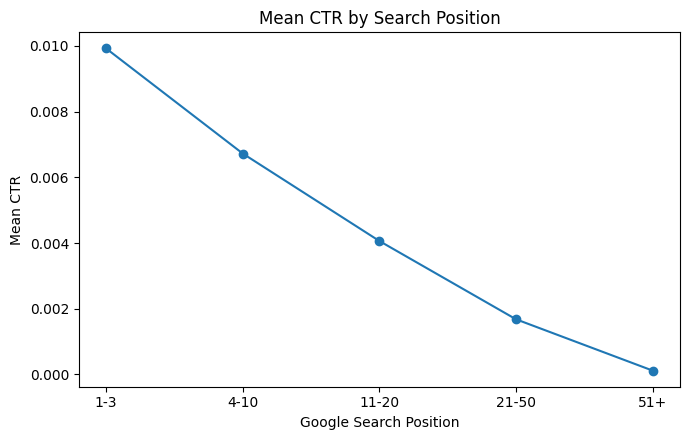

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4.5))

plt.plot(
    position_summary["position_bucket"].astype(str),
    position_summary["mean_ctr"],
    marker="o"
)

plt.xlabel("Google Search Position")
plt.ylabel("Mean CTR")
plt.title("Mean CTR by Search Position")

plt.tight_layout()
plt.savefig("ctr_by_position.png")
plt.show()


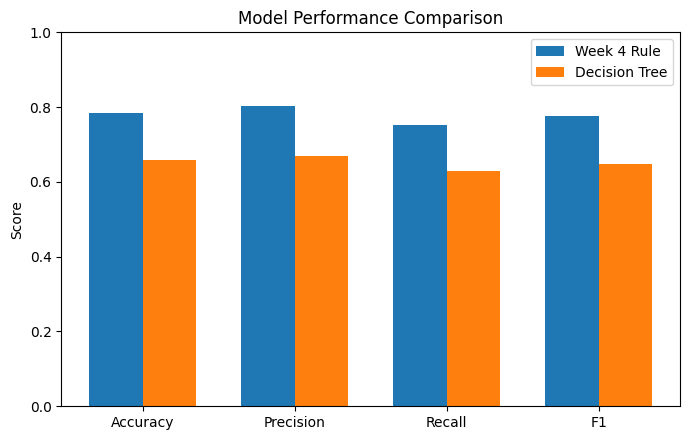

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1"]
baseline_values = [0.7841, 0.8039, 0.7515, 0.7768]
tree_values = [0.6589, 0.6693, 0.6280, 0.6480]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7,4.5))

plt.bar(
    x - width/2,
    baseline_values,
    width,
    label="Week 4 Rule"
)

plt.bar(
    x + width/2,
    tree_values,
    width,
    label="Decision Tree"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.legend()

plt.tight_layout()
plt.savefig("model_performance.png")
plt.show()

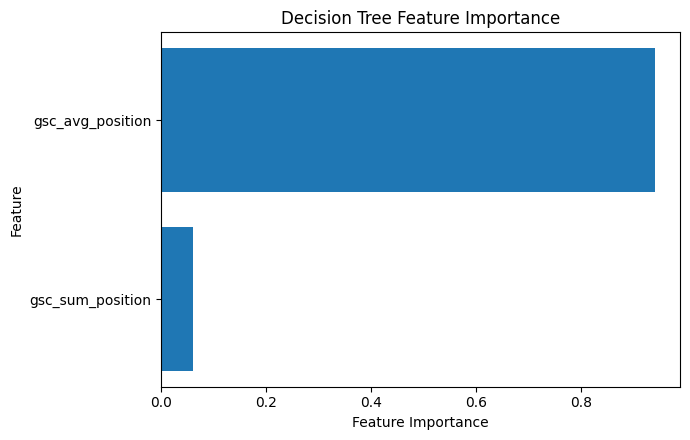

In [ ]:
import matplotlib.pyplot as plt

importance_plot = feature_importance[
    feature_importance["importance"] > 0
].copy()

plt.figure(figsize=(7,4.5))

plt.barh(
    importance_plot["feature"],
    importance_plot["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")

plt.gca().invert_yaxis()
plt.savefig("feature_importance.png")

plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ YES ] Every section above is filled — markdown thinking AND the code that backs it
- [ YES ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ YES ] No client names, URLs, or private queries anywhere
- [ YES ] My claims use careful words: observed, measured, directional, decision-support
- [ YES ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ YES ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ YES ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
